## Main Challenge

For this challenge, you are given various stocks and then are also given an ETF. However, when you open up the data, you will notice that the data is a little messy. Your first job is to clean the data before you work with it. Your goal for this problem is to find all potential mispricings in the ETF and areas where you can capture a profitable position. After you have finished, you are required to summarize your thought process behind your code. Your goal is not to calculate the profit and loss of your trades, but track the places where you see a opportunity to profit. (This could be having a short or long position). A completed project would consist of the following:
- Graph of ETF with blue and red arrows indicating where you would ideally enter a position or close a position.
- Summary describing what specific types of traders would be ideal in that situation and where you think the ETF was mispriced.

You will be graded on how well-written your code is, the strategies you come up with, and your overall documentation. The only packages that you are allowed to implement are pandas, numpy, and matplotlib. These packages are completely optional to use. AI is allowed as long as you document where you use it. Finally, documentation is required and typing is highly recommended.  Happy coding :)

## Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Clean Data

In [2]:
df = pd.read_csv('./price_data.csv')
df

,Stock A,Stock B,Stock C,Stock D,ETF
0,72.82296593982258,248.86456799406784,315.06303215229514,62.13885450318027,102.02002819358744
1,72.78638009022255,248.82753736934225,315.298370904706,62.88303614880522,109.073322883072
2,72.58748777663007,249.73617324185588,317.2996026152549,63.191861836643156,107.832532630003
3,72.85777370841753,248.94553779507217,319.4278357721335,63.53260212860983,115.04142373944143
4,72.32240712454708,249.0104523089816,319.45008634581694,63.649735100785065,115.77710936476478
...,...,...,...,...,...
9995,88.15136765010222,133.49536931750757,406.36515789561105,82.09921243524023,824.7048084981545
9996,88.10489140257589,132.96381630903056,405.7242185064323,82.07582402783335,822.476295069943
9997,87.45860160935052,133.13412226823633,405.6308684653826,82.69330154179573,820.930064686065
9998,87.34087063712745,132.65375269775137,407.5968363177155,83.03887884129337,822.0358541082397


In [3]:
# detect corrupted types 
df.dtypes

Stock A    object
Stock B    object
Stock C    object
Stock D    object
ETF        object
dtype: object

In [4]:
# Convert columns to numerics
for col in ['Stock A', 'Stock B', 'Stock C', 'Stock D', 'ETF']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [5]:
# find missing values
df.isnull().sum()

Stock A    35
Stock B    35
Stock C    39
Stock D    36
ETF        35
dtype: int64

In [6]:
# replace missing values with the mean because thats the best we can do
df.interpolate(method='linear', inplace=True)
df

,Stock A,Stock B,Stock C,Stock D,ETF
0,72.822966,248.864568,315.063032,62.138855,102.020028
1,72.786380,248.827537,315.298371,62.883036,109.073323
2,72.587488,249.736173,317.299603,63.191862,107.832533
3,72.857774,248.945538,319.427836,63.532602,115.041424
4,72.322407,249.010452,319.450086,63.649735,115.777109
...,...,...,...,...,...
9995,88.151368,133.495369,406.365158,82.099212,824.704808
9996,88.104891,132.963816,405.724219,82.075824,822.476295
9997,87.458602,133.134122,405.630868,82.693302,820.930065
9998,87.340871,132.653753,407.596836,83.038879,822.035854


In [7]:
# get the description of the data now
df.describe()

,Stock A,Stock B,Stock C,Stock D,ETF
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,92.712631,179.162621,325.810645,78.128921,397.996833
std,9.419004,41.098299,37.973489,12.525150,194.883639
min,67.823637,128.793632,258.942953,52.500778,78.592611
25%,86.886795,143.772794,294.082356,66.988867,248.568914
50%,91.816721,157.373444,324.337313,78.148338,359.356414
75%,99.850385,225.700054,349.165547,86.022454,527.123471
max,112.936202,249.962313,442.101763,107.685061,867.312303


### Cleaning process:

1. Find corrupted values, these cause the biggest problems as they simply can't have any numerical operations applied on them
2. Convert any corrupted values to numeric types (float64's), if they cant, then turn them into NaN's
3. Interpolate the remaining NaN values, interpolation is a technique used to estimate and fill missing values (NaNs) within a DataFrame or Series. It works by using existing data points to infer the missing values, rather than simply removing rows with NaNs

## Strategy

### Preliminary analysis

1. Take a look at the graphs for each stock and ETF and see what we can do from there
2. After examining the data graphically, its time to implement a simple strategy to find arbitrage opportunities (find points of mispricing and see if its a profitable position)
    - I will collect these positions as an array of indexes and then place labelings on the graph

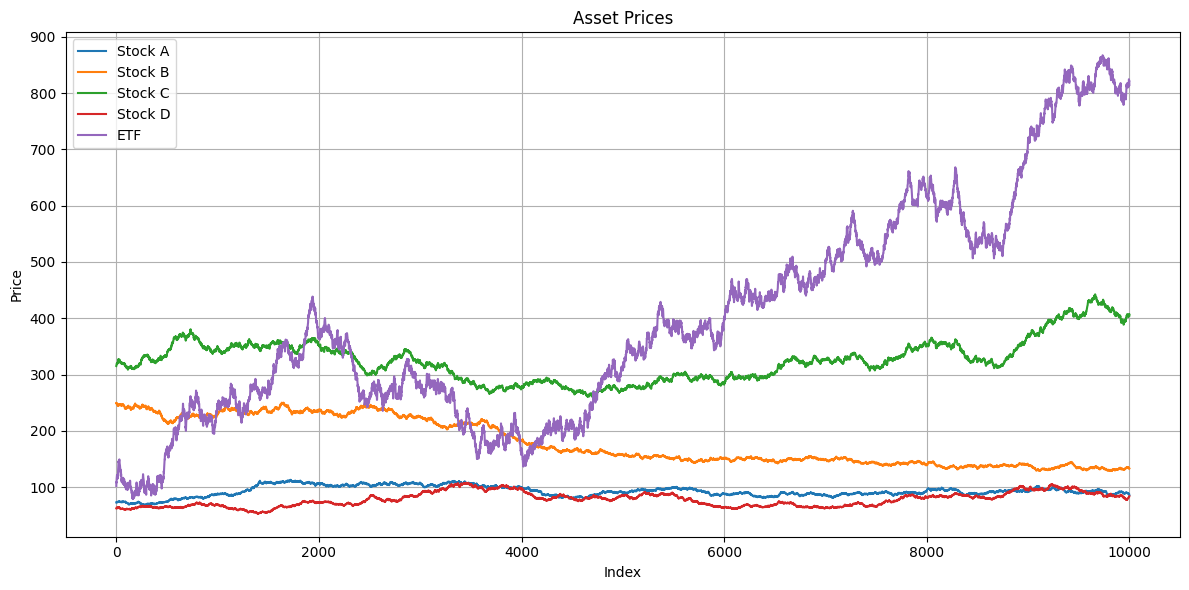

In [8]:
# Take a graph of all stocks and ETF's
def plot_stocks(
    df: pd.DataFrame, 
    columns, x_label: str='Index', 
    y_label: str='Price',
    title: str='Asset Prices'
    ) -> None:
    x = range(len(df))
    plt.figure(figsize=(12, 6))
    for col in columns:
        plt.plot(x, df[col], label=col)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
plot_stocks(df, df.columns)

In [9]:
# Implement strategy
class ZMRS(object):
    def __init__(self, df:pd.DataFrame, lookback: int=20, entry_z: float=2.0, exit_z: float=0.5):
        self.df = df
        self.lookback = lookback
        self.entry_z = entry_z
        self.exit_z = exit_z
    
    def calculate_spread(self):
        self.spread = self.df['ETF'] - df[['Stock A', 'Stock B', 'Stock C', 'Stock D']].mean(axis=1)
        return self.spread
    
    def calculate_zscore(self):
        mean = self.spread.rolling(window=self.lookback).mean()
        std = self.spread.rolling(window=self.lookback).std()
        self.zscore = (self.spread - mean) / std
        return self.zscore
    
    def get_signals(self):
        signals = pd.DataFrame(index=self.df.index, columns=['ETF'])
        signals['ETF'] = np.select(
            [self.zscore > self.entry_z, 
            self.zscore < -self.entry_z, 
            abs(self.zscore) < self.exit_z], 
            [-1, 1, 0], default=np.nan
            )
        signals = signals.ffill().fillna(0)
        return signals
    
    # get a backtest going as well
    def backtest(self):
        self.calculate_spread()
        self.calculate_zscore()
        signals = self.get_signals()
        
        returns = self.df.pct_change()
        strategy_returns = (signals.shift(1) * returns).sum(axis=1)
        cumulative_returns = (1 + strategy_returns).cumprod()
        
        total_return = cumulative_returns.iloc[-1] - 1
        sharpe_ratio = np.sqrt(252) * strategy_returns.mean() / strategy_returns.std()
        max_drawdown = (cumulative_returns / cumulative_returns.cummax() - 1).min()
        
        # Set the signals in the data
        self.df['signals'] = signals['ETF']
        
        return {
            'signals': signals,
            'returns': strategy_returns,
            'cumulative_returns': cumulative_returns,
            'total_return': total_return,
            'sharpe_ratio': sharpe_ratio,
            'max_drawdown': max_drawdown
        }
# Tune z-scores to generate a wide range of results (For example 2.3 and 0.3)
strat = ZMRS(df, entry_z=2.3, exit_z=0.3)
result = strat.backtest()

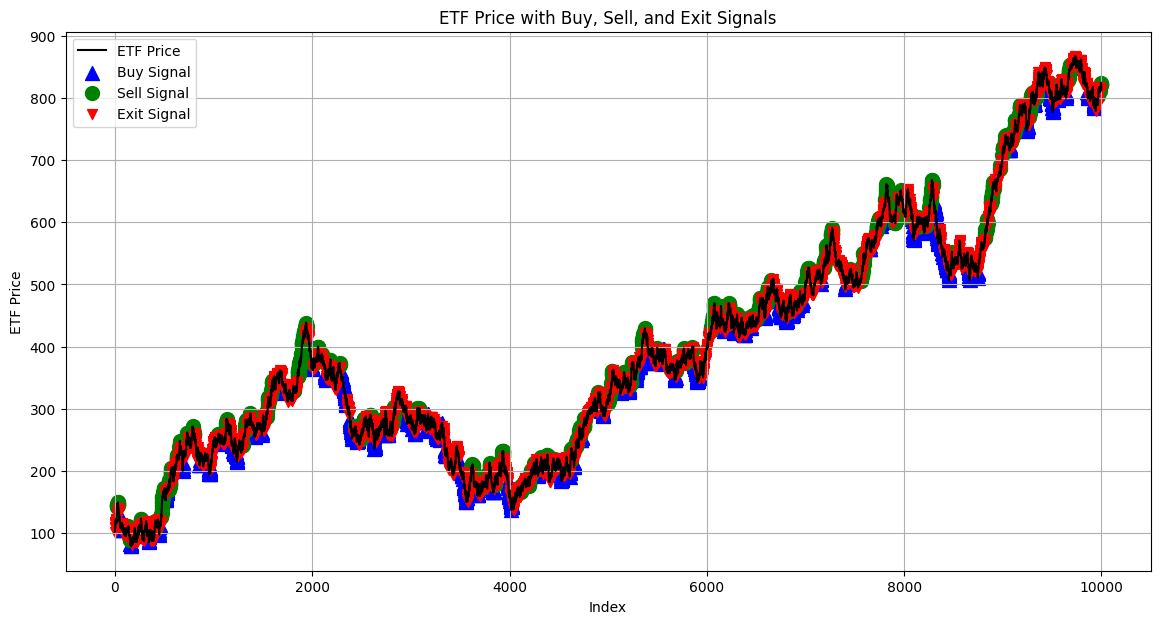

In [ ]:
# grab our signal indexes
buy_signals = df[df['signals'] == 1]
sell_signals = df[df['signals'] == -1]
exit_signals = df[df['signals'] == 0]

# Plot the ETF price
plt.figure(figsize=(14, 7))
plt.plot(df['ETF'], label='ETF Price', color='black')

# Plot buy signals
plt.scatter(buy_signals.index, buy_signals['ETF'], marker='^', color='blue', label='Buy Signal', s=100)

# Plot sell signals
plt.scatter(sell_signals.index, sell_signals['ETF'], marker='o', color='green', label='Sell Signal', s=100)

# Plot exit signals
plt.scatter(exit_signals.index, exit_signals['ETF'], marker='v', color='red', label='Exit Signal', s=50)

# Formatting
plt.title('ETF Price with Buy, Sell, and Exit Signals')
plt.xlabel('Index')
plt.ylabel('ETF Price')
plt.legend()
plt.grid(True)
plt.show()

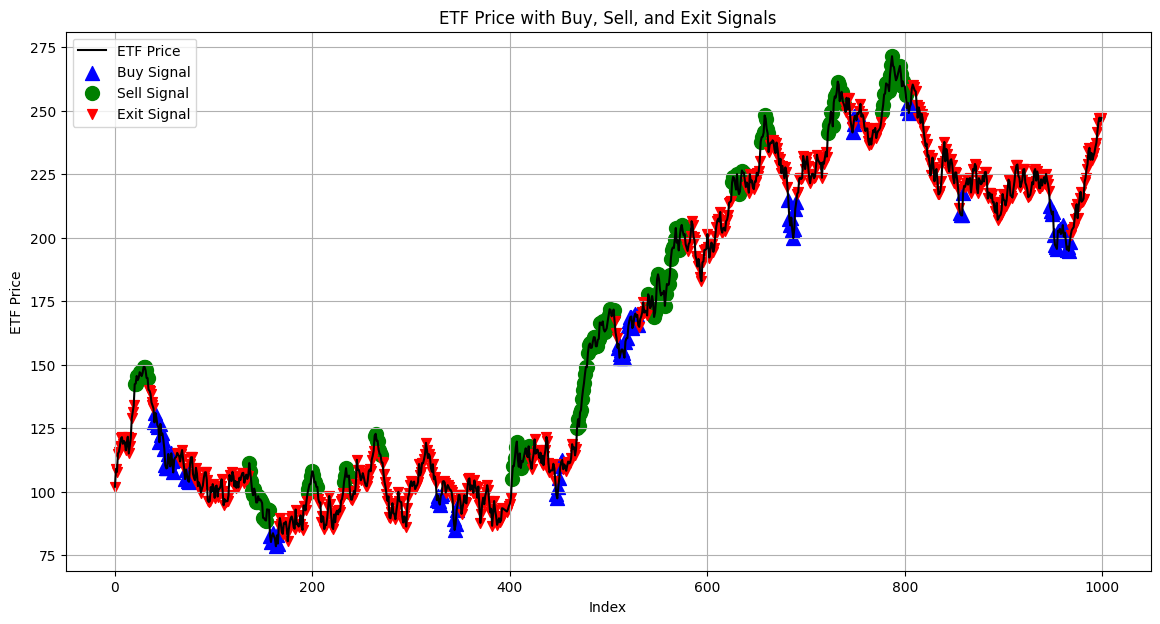

In [11]:
# Since there is 10000 data points here, here is 1000 to better see whats going on
df_subset = df.iloc[0:1000]
buy_signals = df_subset[df_subset['signals'] == 1]
sell_signals = df_subset[df_subset['signals'] == -1]
exit_signals = df_subset[df_subset['signals'] == 0]

# Plot the ETF price
plt.figure(figsize=(14, 7))
plt.plot(df_subset['ETF'], label='ETF Price', color='black')

# Plot buy signals
plt.scatter(buy_signals.index, buy_signals['ETF'], marker='^', color='blue', label='Buy Signal', s=100)

# Plot sell signals
plt.scatter(sell_signals.index, sell_signals['ETF'], marker='o', color='green', label='Sell Signal', s=100)

# Plot exit signals
plt.scatter(exit_signals.index, exit_signals['ETF'], marker='v', color='red', label='Exit Signal', s=50)

# Formatting
plt.title('ETF Price with Buy, Sell, and Exit Signals')
plt.xlabel('Index')
plt.ylabel('ETF Price')
plt.legend()
plt.grid(True)
plt.show()

## Summary

### Strategy Implemented: Z-Score Mean Reversion

#### Trading strategy implemented

I decided to utilize Z-Score mean reversion to look for **short-term** arbitrage opportunities. The reason I chose this is ease of implementation, being able to generate a large amount of entry (buy), sell, and exit signals, and being a solid and reliable strategy to utilize in a static dataset for our 10000 row dataset.

#### Logic and Math behind approach

For my strategy, I begin by calculating the *spread* of the data. This is done by subtracting the ETF column by the **Fair Value Price** of the stock. This allows me to see any potential mispricing that may have occurred for the ETF. In pair trading, we assume this spread has a long-term equilibrium. The strategy profits when the spread deviates from and then returns to this equilibrium.

Next, we calcuate the Z-Score, by measuring how many standard deviations the spread is from its mean. This is calculated using a rolling window (this is the lookback variable) to adapt to potential market conditions. A high absolute z-score indicates a potential trading opportunity in our strategy.

Then, we actually generate our trading signals:
1. If z_score > entry_z, then generate a sell signal
2. If z_score < -entry_z, then generate a buy signal
3. If abs(z_score) < exit_z, exit the position
4. These signals are forward-filled to maintain positions until a new signal occurs

I then perform a backtest of this strategy later. We can easily tune this by changing up entry and exit z-scores, or even applying weights towards the stocks if need be.

#### How profit is generated

I simply take the cummulative returns from my buy and sell signals from the entire process, given this data is not *exactly* time series (as there are only indexes), I evaluate the performance of my strategy by taking its cummulative returns with the final return being the total return of the entire strategy. I also take the sharpe ratio and max drawdown, this strategy is to be low-risk low-reward, given the numerous signals generated throughout the process (but overtrading may also occur in a real scenario).


## Bonus
Calculate the Profit and Loss of your strategy.

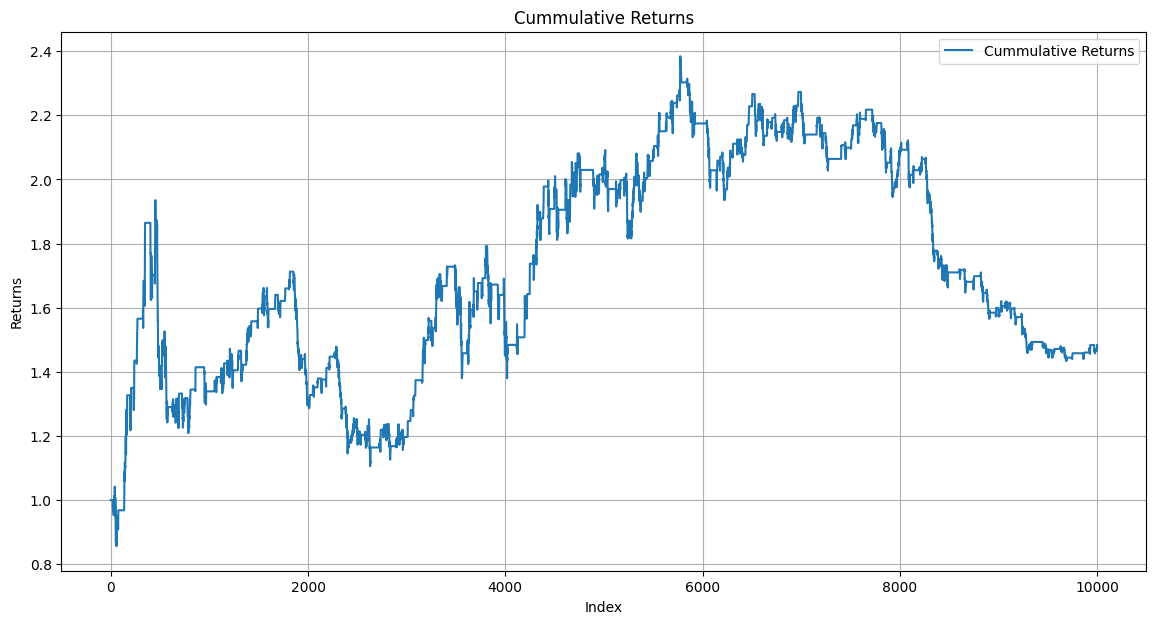

In [12]:
plt.figure(figsize=(14, 7))
plt.plot(result['cumulative_returns'], label='Cummulative Returns')
plt.title('Cummulative Returns')
plt.xlabel('Index')
plt.ylabel('Returns')
plt.legend()
plt.grid(True)
plt.show()

Text(0.5, 1.0, 'Trading Signals (Z-score)')

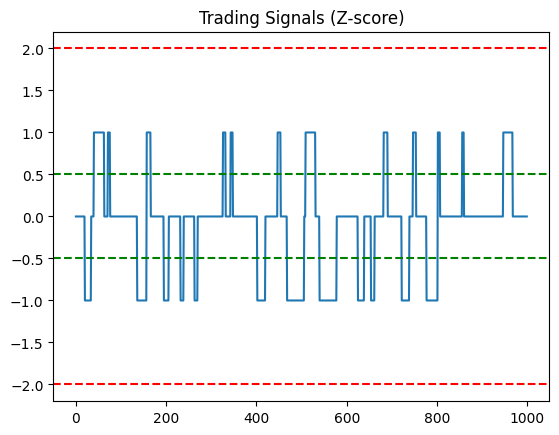

In [13]:
# Plot Z-score and entry/exit thresholds (only the first 1000)
sub_signal = result['signals'].iloc[0:1000]
plt.plot(sub_signal.index, sub_signal.iloc[:, 0])
plt.axhline(y=2.0, color='r', linestyle='--')
plt.axhline(y=-2.0, color='r', linestyle='--')
plt.axhline(y=0.5, color='g', linestyle='--')
plt.axhline(y=-0.5, color='g', linestyle='--')
plt.title('Trading Signals (Z-score)')

In [14]:
print("Results:")
print(f"Total Returns: {result['total_return']}")
print(f"Sharpe Ratio: {result['sharpe_ratio']}")
print(f"Max Drawdown: {result['max_drawdown']}")

Results:
Total Returns: 0.48361239159497904
Sharpe Ratio: 0.14468483041070013
Max Drawdown: -0.4287444722616123
